In [1]:
# ============================================
# Cell 1: Setup
# ============================================

from google.colab import drive
drive.mount("/content/drive")

import os
import pandas as pd
import numpy as np

BASE_DIR = "/content/drive/MyDrive/気合のCOVID19"

OUT_DIR = os.path.join(
    BASE_DIR,
    "04_全モデル比較・統計解析"
)

os.makedirs(OUT_DIR, exist_ok=True)

print("BASE_DIR:", BASE_DIR)
print("OUT_DIR :", OUT_DIR)

Mounted at /content/drive
BASE_DIR: /content/drive/MyDrive/気合のCOVID19
OUT_DIR : /content/drive/MyDrive/気合のCOVID19/04_全モデル比較・統計解析


In [2]:
# ============================================
# Cell 2: Load patient-level Test predictions
# ============================================

CXR_PATH = os.path.join(
    BASE_DIR,
    "01_TaskA_CXR",
    "05_Evaluation",
    "TaskA_CXR_Test患者別予測結果.csv"
)

LR_PATH = os.path.join(
    BASE_DIR,
    "02_TaskB_臨床データ",
    "05_Evaluation",
    "TaskB_LR_Test患者別予測.csv"
)

XGB_PATH = os.path.join(
    BASE_DIR,
    "02_TaskB_臨床データ",
    "05_Evaluation",
    "TaskB_XGBoost_Test患者別予測.csv"
)

MLP_PATH = os.path.join(
    BASE_DIR,
    "02_TaskB_臨床データ",
    "05_Evaluation",
    "TaskB_MLP_Test患者別予測.csv"
)

FUSION_PATH = os.path.join(
    BASE_DIR,
    "03_TaskC_マルチモーダル",
    "TaskC_LateFusion_Test患者別予測結果.csv"
)

paths = {
    "CXR": CXR_PATH,
    "LR": LR_PATH,
    "XGBoost": XGB_PATH,
    "MLP": MLP_PATH,
    "Late Fusion": FUSION_PATH
}

print("=== File check ===")

for name, path in paths.items():
    print(f"{name:12s}: {os.path.exists(path)}")

=== File check ===
CXR         : True
LR          : True
XGBoost     : True
MLP         : True
Late Fusion : True


In [3]:
# ============================================
# Cell 3: Inspect columns
# ============================================

dfs = {
    "CXR": pd.read_csv(CXR_PATH),
    "LR": pd.read_csv(LR_PATH),
    "XGBoost": pd.read_csv(XGB_PATH),
    "MLP": pd.read_csv(MLP_PATH),
    "Late Fusion": pd.read_csv(FUSION_PATH)
}

for name, df in dfs.items():
    print(f"\n=== {name} ===")
    print("Shape   :", df.shape)
    print("Columns :", df.columns.tolist())
    display(df.head())


=== CXR ===
Shape   : (128, 6)
Columns : ['Subject ID', 'true_label', 'prob_death', 'pred_label', 'correct', 'model_name']


,Subject ID,true_label,prob_death,pred_label,correct,model_name
0,A507869,1,0.629968,1,1,CXR_ResNet18
1,A590353,0,0.150122,0,1,CXR_ResNet18
2,A292777,1,0.337573,0,0,CXR_ResNet18
3,A071731,0,0.396800,0,1,CXR_ResNet18
4,A843575,0,0.239269,0,1,CXR_ResNet18



=== LR ===
Shape   : (128, 4)
Columns : ['Subject ID', 'true_label', 'prob', 'pred']


,Subject ID,true_label,prob,pred
0,A387558,1,0.799579,1
1,A642300,1,0.885586,1
2,A769593,1,0.294029,1
3,A104425,0,0.027194,0
4,A919435,0,0.430578,1



=== XGBoost ===
Shape   : (128, 4)
Columns : ['Subject ID', 'true_label', 'prob', 'pred']


,Subject ID,true_label,prob,pred
0,A387558,1,0.455373,1
1,A642300,1,0.620095,1
2,A769593,1,0.212409,1
3,A104425,0,0.148167,1
4,A919435,0,0.356149,1



=== MLP ===
Shape   : (128, 4)
Columns : ['Subject ID', 'true_label', 'prob', 'pred']


,Subject ID,true_label,prob,pred
0,A387558,1,0.643152,1
1,A642300,1,0.731202,1
2,A769593,1,0.515946,1
3,A104425,0,0.410286,0
4,A919435,0,0.569114,1



=== Late Fusion ===
Shape   : (128, 5)
Columns : ['Subject ID', 'true_label', 'cxr_prob', 'clinical_prob', 'latefusion_prob']


,Subject ID,true_label,cxr_prob,clinical_prob,latefusion_prob
0,A507869,1,0.629968,0.650525,0.644769
1,A590353,0,0.150122,0.020699,0.056937
2,A292777,1,0.337573,0.136580,0.192858
3,A071731,0,0.396800,0.181427,0.241731
4,A843575,0,0.239269,0.215611,0.222236


In [4]:
# ============================================
# Cell 4: Merge all 5 models by Subject ID
# ============================================

# Late Fusion tableを土台にする
all_models_test = dfs["Late Fusion"][
    [
        "Subject ID",
        "true_label",
        "cxr_prob",
        "clinical_prob",
        "latefusion_prob"
    ]
].copy()

# LR
lr_use = dfs["LR"][
    ["Subject ID", "true_label", "prob"]
].rename(
    columns={
        "true_label": "true_label_lr",
        "prob": "lr_prob"
    }
)

# XGBoost
xgb_use = dfs["XGBoost"][
    ["Subject ID", "true_label", "prob"]
].rename(
    columns={
        "true_label": "true_label_xgb",
        "prob": "xgb_prob"
    }
)

# MLP
mlp_use = dfs["MLP"][
    ["Subject ID", "true_label", "prob"]
].rename(
    columns={
        "true_label": "true_label_mlp",
        "prob": "mlp_prob"
    }
)

# Subject IDで1対1結合
all_models_test = (
    all_models_test
    .merge(
        lr_use,
        on="Subject ID",
        how="inner",
        validate="one_to_one"
    )
    .merge(
        xgb_use,
        on="Subject ID",
        how="inner",
        validate="one_to_one"
    )
    .merge(
        mlp_use,
        on="Subject ID",
        how="inner",
        validate="one_to_one"
    )
)

print("Shape:", all_models_test.shape)
display(all_models_test.head())

Shape: (128, 11)


,Subject ID,true_label,cxr_prob,clinical_prob,latefusion_prob,true_label_lr,lr_prob,true_label_xgb,xgb_prob,true_label_mlp,mlp_prob
0,A507869,1,0.629968,0.650525,0.644769,1,0.650525,1,0.470090,1,0.833411
1,A590353,0,0.150122,0.020699,0.056937,0,0.020699,0,0.161328,0,0.278655
2,A292777,1,0.337573,0.136580,0.192858,1,0.136580,1,0.135814,1,0.441389
3,A071731,0,0.396800,0.181427,0.241731,0,0.181427,0,0.119844,0,0.425955
4,A843575,0,0.239269,0.215611,0.222236,0,0.215611,0,0.229729,0,0.445785


In [5]:
# ============================================
# Cell 5: Audit merged 5-model Test table
# ============================================

print("=== 5-model Test audit ===")

print("Rows       :", len(all_models_test))
print("Unique IDs :", all_models_test["Subject ID"].nunique())
print("Deaths     :", int(all_models_test["true_label"].sum()))

# ラベル一致
lr_label_match = (
    all_models_test["true_label"]
    == all_models_test["true_label_lr"]
).all()

xgb_label_match = (
    all_models_test["true_label"]
    == all_models_test["true_label_xgb"]
).all()

mlp_label_match = (
    all_models_test["true_label"]
    == all_models_test["true_label_mlp"]
).all()

print("LR labels match  :", lr_label_match)
print("XGB labels match :", xgb_label_match)
print("MLP labels match :", mlp_label_match)

# Late Fusionに入っているClinical予測と
# Task B LR予測が完全一致するか確認
clinical_prob_match = np.allclose(
    all_models_test["clinical_prob"],
    all_models_test["lr_prob"],
    rtol=0,
    atol=1e-12
)

print("Fusion Clinical == LR :", clinical_prob_match)

# 各予測確率
prob_cols = [
    "cxr_prob",
    "lr_prob",
    "xgb_prob",
    "mlp_prob",
    "latefusion_prob"
]

print("\nMissing probabilities:")
print(all_models_test[prob_cols].isna().sum())

print("\nProbability ranges:")
for col in prob_cols:
    print(
        f"{col:16s}: "
        f"{all_models_test[col].min():.6f} "
        f"to {all_models_test[col].max():.6f}"
    )

# 最終assert
assert len(all_models_test) == 128
assert all_models_test["Subject ID"].nunique() == 128
assert int(all_models_test["true_label"].sum()) == 17

assert lr_label_match
assert xgb_label_match
assert mlp_label_match

assert clinical_prob_match

assert all_models_test[prob_cols].isna().sum().sum() == 0

for col in prob_cols:
    assert all_models_test[col].between(0, 1).all()

print("\n✅ Audit OK")

=== 5-model Test audit ===
Rows       : 128
Unique IDs : 128
Deaths     : 17
LR labels match  : True
XGB labels match : True
MLP labels match : True
Fusion Clinical == LR : True

Missing probabilities:
cxr_prob           0
lr_prob            0
xgb_prob           0
mlp_prob           0
latefusion_prob    0
dtype: int64

Probability ranges:
cxr_prob        : 0.017999 to 0.975495
lr_prob         : 0.000979 to 0.987930
xgb_prob        : 0.023186 to 0.794855
mlp_prob        : 0.189112 to 0.916366
latefusion_prob : 0.010952 to 0.979634

✅ Audit OK


In [6]:
# ============================================
# Cell 6: Save unified patient-level predictions
# ============================================

FINAL_PRED_PATH = os.path.join(
    OUT_DIR,
    "全5モデル_Test患者別予測確率.csv"
)

final_pred_table = all_models_test[
    [
        "Subject ID",
        "true_label",
        "cxr_prob",
        "lr_prob",
        "xgb_prob",
        "mlp_prob",
        "latefusion_prob"
    ]
].copy()

final_pred_table.to_csv(
    FINAL_PRED_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("Saved:", FINAL_PRED_PATH)
print("Shape :", final_pred_table.shape)
display(final_pred_table.head())

Saved: /content/drive/MyDrive/気合のCOVID19/04_全モデル比較・統計解析/全5モデル_Test患者別予測確率.csv
Shape : (128, 7)


,Subject ID,true_label,cxr_prob,lr_prob,xgb_prob,mlp_prob,latefusion_prob
0,A507869,1,0.629968,0.650525,0.470090,0.833411,0.644769
1,A590353,0,0.150122,0.020699,0.161328,0.278655,0.056937
2,A292777,1,0.337573,0.136580,0.135814,0.441389,0.192858
3,A071731,0,0.396800,0.181427,0.119844,0.425955,0.241731
4,A843575,0,0.239269,0.215611,0.229729,0.445785,0.222236


In [7]:
# ============================================
# Cell 7: Final 5-model Test performance table
# ============================================

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)

def expected_calibration_error(y_true, y_prob, n_bins=10):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0

    for i in range(n_bins):
        if i < n_bins - 1:
            mask = (
                (y_prob >= bin_edges[i]) &
                (y_prob < bin_edges[i + 1])
            )
        else:
            mask = (
                (y_prob >= bin_edges[i]) &
                (y_prob <= bin_edges[i + 1])
            )

        if mask.sum() == 0:
            continue

        observed = y_true[mask].mean()
        predicted = y_prob[mask].mean()

        ece += mask.mean() * abs(observed - predicted)

    return ece


def stratified_bootstrap_auc_ci(
    y_true,
    y_prob,
    n_boot=10000,
    seed=42,
    alpha=0.05
):
    rng = np.random.default_rng(seed)

    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)

    pos_idx = np.where(y_true == 1)[0]
    neg_idx = np.where(y_true == 0)[0]

    boot_aucs = []

    for _ in range(n_boot):

        boot_pos = rng.choice(
            pos_idx,
            size=len(pos_idx),
            replace=True
        )

        boot_neg = rng.choice(
            neg_idx,
            size=len(neg_idx),
            replace=True
        )

        boot_idx = np.concatenate([
            boot_pos,
            boot_neg
        ])

        boot_aucs.append(
            roc_auc_score(
                y_true[boot_idx],
                y_prob[boot_idx]
            )
        )

    boot_aucs = np.asarray(boot_aucs)

    ci_low = np.percentile(
        boot_aucs,
        100 * alpha / 2
    )

    ci_high = np.percentile(
        boot_aucs,
        100 * (1 - alpha / 2)
    )

    return ci_low, ci_high


y = final_pred_table["true_label"].values

model_probs = {
    "CXR ResNet18": final_pred_table["cxr_prob"].values,
    "Clinical LR": final_pred_table["lr_prob"].values,
    "Clinical XGBoost": final_pred_table["xgb_prob"].values,
    "Clinical MLP": final_pred_table["mlp_prob"].values,
    "Late Fusion": final_pred_table["latefusion_prob"].values,
}

rows = []

for model_name, prob in model_probs.items():

    roc_auc = roc_auc_score(y, prob)
    pr_auc = average_precision_score(y, prob)
    brier = brier_score_loss(y, prob)
    ece = expected_calibration_error(
        y,
        prob,
        n_bins=10
    )

    ci_low, ci_high = stratified_bootstrap_auc_ci(
        y,
        prob,
        n_boot=10000,
        seed=42
    )

    rows.append({
        "model": model_name,
        "roc_auc": roc_auc,
        "ci95_lower": ci_low,
        "ci95_upper": ci_high,
        "pr_auc": pr_auc,
        "brier_score": brier,
        "ece": ece
    })

all_model_metrics = pd.DataFrame(rows)

print("=== Final 5-model Test comparison ===")
display(all_model_metrics)

=== Final 5-model Test comparison ===


,model,roc_auc,ci95_lower,ci95_upper,pr_auc,brier_score,ece
0,CXR ResNet18,0.907260,0.835718,0.962904,0.622926,0.101732,0.152336
1,Clinical LR,0.941176,0.887122,0.981452,0.800251,0.057177,0.041302
2,Clinical XGBoost,0.935877,0.875980,0.979332,0.718188,0.067800,0.090264
3,Clinical MLP,0.879703,0.767886,0.960784,0.688972,0.168616,0.308812
4,Late Fusion,0.944356,0.884473,0.985162,0.797135,0.059210,0.064514


In [8]:
# ============================================
# Cell 8: Save final 5-model comparison table
# ============================================

METRICS_PATH = os.path.join(
    OUT_DIR,
    "全5モデル_最終Test評価比較.csv"
)

all_model_metrics.to_csv(
    METRICS_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("Saved:", METRICS_PATH)

Saved: /content/drive/MyDrive/気合のCOVID19/04_全モデル比較・統計解析/全5モデル_最終Test評価比較.csv


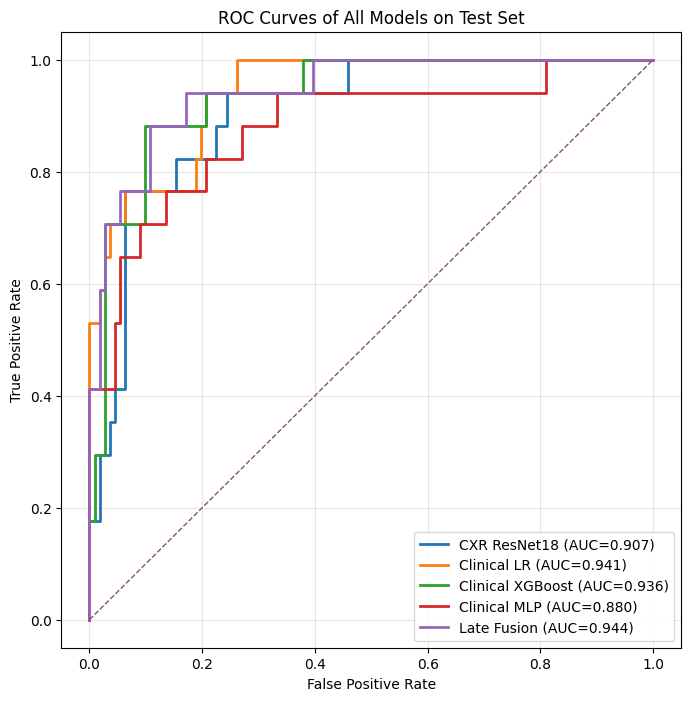

Saved: /content/drive/MyDrive/気合のCOVID19/04_全モデル比較・統計解析/全5モデル_Test_ROC_curve.png


In [9]:
# ============================================
# Cell 9: Plot ROC curves for all 5 models
# ============================================

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(8, 8))

for model_name, prob in model_probs.items():

    fpr, tpr, _ = roc_curve(y, prob)
    model_auc = roc_auc_score(y, prob)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{model_name} (AUC={model_auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves of All Models on Test Set")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

ALL_ROC_FIG_PATH = os.path.join(
    OUT_DIR,
    "全5モデル_Test_ROC_curve.png"
)

plt.savefig(
    ALL_ROC_FIG_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", ALL_ROC_FIG_PATH)

In [11]:
# ============================================
# Cell 11: Paired DeLong test functions
# ============================================

from scipy.stats import norm
import numpy as np
import pandas as pd


def compute_midrank(x):
    J = np.argsort(x)
    Z = x[J]

    N = len(x)
    T = np.zeros(N, dtype=float)

    i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1

        T[i:j] = 0.5 * (i + j - 1) + 1
        i = j

    T2 = np.empty(N, dtype=float)
    T2[J] = T

    return T2


def fast_delong(predictions_sorted_transposed, label_1_count):

    m = label_1_count
    n = predictions_sorted_transposed.shape[1] - m

    positive_examples = predictions_sorted_transposed[:, :m]
    negative_examples = predictions_sorted_transposed[:, m:]

    k = predictions_sorted_transposed.shape[0]

    tx = np.empty([k, m], dtype=float)
    ty = np.empty([k, n], dtype=float)
    tz = np.empty([k, m + n], dtype=float)

    for r in range(k):
        tx[r, :] = compute_midrank(
            positive_examples[r, :]
        )
        ty[r, :] = compute_midrank(
            negative_examples[r, :]
        )
        tz[r, :] = compute_midrank(
            predictions_sorted_transposed[r, :]
        )

    aucs = (
        tz[:, :m].sum(axis=1) / m / n
        - (m + 1.0) / 2.0 / n
    )

    v01 = (
        tz[:, :m] - tx
    ) / n

    v10 = (
        1.0
        - (tz[:, m:] - ty) / m
    )

    sx = np.cov(v01)
    sy = np.cov(v10)

    delongcov = sx / m + sy / n

    return aucs, delongcov


def delong_roc_test(y_true, pred1, pred2):

    y_true = np.asarray(y_true)
    pred1 = np.asarray(pred1)
    pred2 = np.asarray(pred2)

    order = np.argsort(-y_true)

    y_sorted = y_true[order]

    preds = np.vstack([
        pred1[order],
        pred2[order]
    ])

    label_1_count = int(y_sorted.sum())

    aucs, covariance = fast_delong(
        preds,
        label_1_count
    )

    diff = aucs[0] - aucs[1]

    var = (
        covariance[0, 0]
        + covariance[1, 1]
        - 2 * covariance[0, 1]
    )

    se = np.sqrt(var)
    z = diff / se
    p = 2 * norm.sf(abs(z))

    return {
        "auc_1": aucs[0],
        "auc_2": aucs[1],
        "auc_difference": diff,
        "standard_error": se,
        "z": z,
        "p_value": p
    }

print("DeLong functions loaded.")

DeLong functions loaded.


In [12]:
# ============================================
# Cell 12: Late Fusion vs 3 clinical models
# ============================================

clinical_comparisons = [
    (
        "Late Fusion",
        final_pred_table["latefusion_prob"].values,
        "Clinical LR",
        final_pred_table["lr_prob"].values
    ),
    (
        "Late Fusion",
        final_pred_table["latefusion_prob"].values,
        "Clinical XGBoost",
        final_pred_table["xgb_prob"].values
    ),
    (
        "Late Fusion",
        final_pred_table["latefusion_prob"].values,
        "Clinical MLP",
        final_pred_table["mlp_prob"].values
    )
]

fusion_vs_clinical_results = []

for name1, pred1, name2, pred2 in clinical_comparisons:

    result = delong_roc_test(
        y,
        pred1,
        pred2
    )

    fusion_vs_clinical_results.append({
        "comparison": f"{name1} vs {name2}",
        **result
    })

fusion_vs_clinical_df = pd.DataFrame(
    fusion_vs_clinical_results
)

print("=== Late Fusion vs Clinical models: paired DeLong ===")
display(fusion_vs_clinical_df)

=== Late Fusion vs Clinical models: paired DeLong ===


,comparison,auc_1,auc_2,auc_difference,standard_error,z,p_value
0,Late Fusion vs Clinical LR,0.944356,0.941176,0.003180,0.013325,0.238624,0.811397
1,Late Fusion vs Clinical XGBoost,0.944356,0.935877,0.008479,0.011869,0.714408,0.474975
2,Late Fusion vs Clinical MLP,0.944356,0.879703,0.064653,0.027928,2.315001,0.020613


In [13]:
# ============================================
# Cell 12: Holm correction for 3 comparisons
# ============================================

from statsmodels.stats.multitest import multipletests

reject, p_holm, _, _ = multipletests(
    fusion_vs_clinical_df["p_value"].values,
    alpha=0.05,
    method="holm"
)

fusion_vs_clinical_df["p_holm"] = p_holm
fusion_vs_clinical_df["significant_holm"] = reject

print("=== Late Fusion vs 3 Clinical models ===")
print("=== Paired DeLong + Holm correction ===")
display(fusion_vs_clinical_df)

=== Late Fusion vs 3 Clinical models ===
=== Paired DeLong + Holm correction ===


,comparison,auc_1,auc_2,auc_difference,standard_error,z,p_value,p_holm,significant_holm
0,Late Fusion vs Clinical LR,0.944356,0.941176,0.003180,0.013325,0.238624,0.811397,0.949950,False
1,Late Fusion vs Clinical XGBoost,0.944356,0.935877,0.008479,0.011869,0.714408,0.474975,0.949950,False
2,Late Fusion vs Clinical MLP,0.944356,0.879703,0.064653,0.027928,2.315001,0.020613,0.061839,False


In [14]:
# ============================================
# Cell 13: Save Late Fusion vs Clinical models
# DeLong + Holm results
# ============================================

FUSION_CLINICAL_DELONG_PATH = os.path.join(
    OUT_DIR,
    "LateFusion_vs_Clinical3モデル_DeLong_Holm.csv"
)

fusion_vs_clinical_df.to_csv(
    FUSION_CLINICAL_DELONG_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("Saved:", FUSION_CLINICAL_DELONG_PATH)

Saved: /content/drive/MyDrive/気合のCOVID19/04_全モデル比較・統計解析/LateFusion_vs_Clinical3モデル_DeLong_Holm.csv


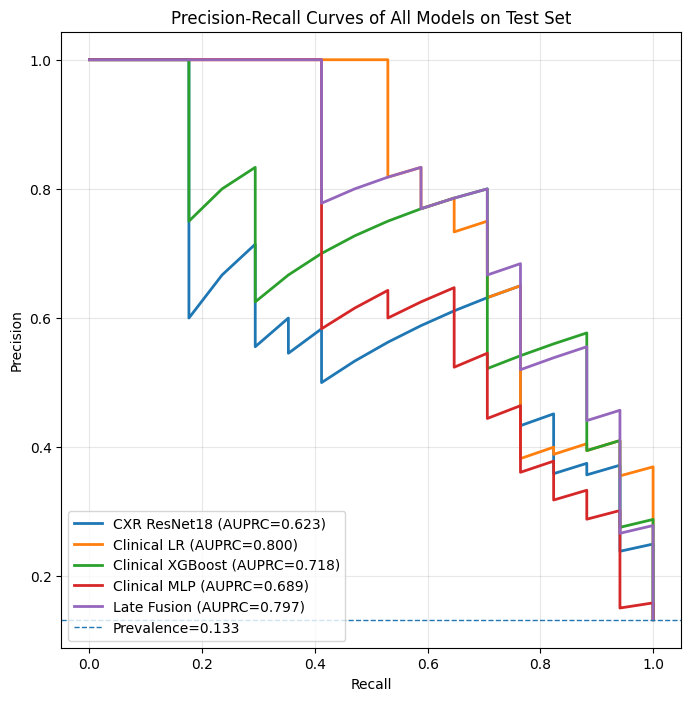

Saved: /content/drive/MyDrive/気合のCOVID19/04_全モデル比較・統計解析/全5モデル_Test_PR_curve.png


In [15]:
# ============================================
# Cell 14: Plot PR curves for all 5 models
# ============================================

import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(8, 8))

for model_name, prob in model_probs.items():

    precision, recall, _ = precision_recall_curve(
        y,
        prob
    )

    ap = average_precision_score(
        y,
        prob
    )

    plt.plot(
        recall,
        precision,
        linewidth=2,
        label=f"{model_name} (AUPRC={ap:.3f})"
    )

# Test set prevalence
prevalence = y.mean()

plt.axhline(
    prevalence,
    linestyle="--",
    linewidth=1,
    label=f"Prevalence={prevalence:.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves of All Models on Test Set")
plt.legend(loc="best")
plt.grid(alpha=0.3)

ALL_PR_FIG_PATH = os.path.join(
    OUT_DIR,
    "全5モデル_Test_PR_curve.png"
)

plt.savefig(
    ALL_PR_FIG_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", ALL_PR_FIG_PATH)

In [16]:
# ============================================
# Cell 15: Save PR curve data
# ============================================

pr_rows = []

for model_name, prob in model_probs.items():

    precision, recall, thresholds = precision_recall_curve(
        y,
        prob
    )

    thresholds_full = list(thresholds) + [float("nan")]

    temp = pd.DataFrame({
        "model": model_name,
        "precision": precision,
        "recall": recall,
        "threshold": thresholds_full
    })

    pr_rows.append(temp)

all_pr_data = pd.concat(
    pr_rows,
    ignore_index=True
)

ALL_PR_DATA_PATH = os.path.join(
    OUT_DIR,
    "全5モデル_Test_PR_curve_data.csv"
)

all_pr_data.to_csv(
    ALL_PR_DATA_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("Saved:", ALL_PR_DATA_PATH)

Saved: /content/drive/MyDrive/気合のCOVID19/04_全モデル比較・統計解析/全5モデル_Test_PR_curve_data.csv


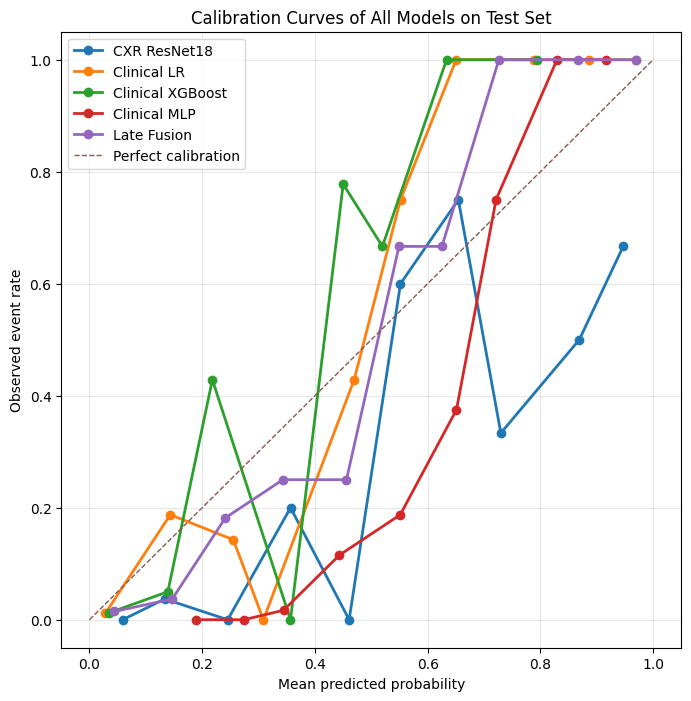

Saved: /content/drive/MyDrive/気合のCOVID19/04_全モデル比較・統計解析/全5モデル_Test_Calibration_curve.png


In [17]:
# ============================================
# Cell 16: Plot calibration curves for all 5 models
# ============================================

import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

plt.figure(figsize=(8, 8))

for model_name, prob in model_probs.items():

    frac_pos, mean_pred = calibration_curve(
        y,
        prob,
        n_bins=10,
        strategy="uniform"
    )

    plt.plot(
        mean_pred,
        frac_pos,
        marker="o",
        linewidth=2,
        label=model_name
    )

# Perfect calibration
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1,
    label="Perfect calibration"
)

plt.xlabel("Mean predicted probability")
plt.ylabel("Observed event rate")
plt.title("Calibration Curves of All Models on Test Set")
plt.legend(loc="best")
plt.grid(alpha=0.3)

CAL_FIG_PATH = os.path.join(
    OUT_DIR,
    "全5モデル_Test_Calibration_curve.png"
)

plt.savefig(
    CAL_FIG_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", CAL_FIG_PATH)

In [18]:
# ============================================
# Cell 17: Save calibration curve data
# ============================================

cal_rows = []

for model_name, prob in model_probs.items():

    frac_pos, mean_pred = calibration_curve(
        y,
        prob,
        n_bins=10,
        strategy="uniform"
    )

    temp = pd.DataFrame({
        "model": model_name,
        "mean_predicted_probability": mean_pred,
        "observed_event_rate": frac_pos
    })

    cal_rows.append(temp)

all_calibration_data = pd.concat(
    cal_rows,
    ignore_index=True
)

CAL_DATA_PATH = os.path.join(
    OUT_DIR,
    "全5モデル_Test_Calibration_curve_data.csv"
)

all_calibration_data.to_csv(
    CAL_DATA_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("Saved:", CAL_DATA_PATH)

Saved: /content/drive/MyDrive/気合のCOVID19/04_全モデル比較・統計解析/全5モデル_Test_Calibration_curve_data.csv


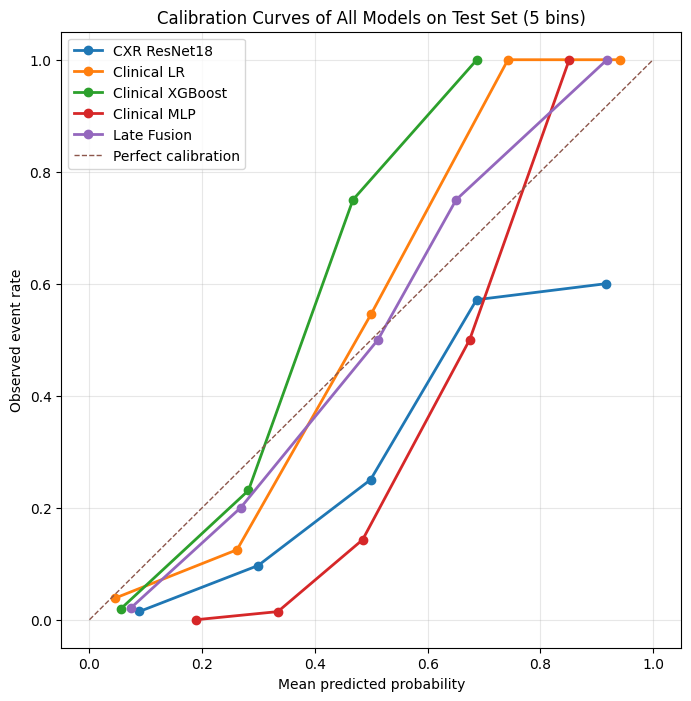

Saved: /content/drive/MyDrive/気合のCOVID19/04_全モデル比較・統計解析/全5モデル_Test_Calibration_curve_5bins.png


In [19]:
# ============================================
# Cell 18: Calibration curves with 5 bins
# ============================================

import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

plt.figure(figsize=(8, 8))

for model_name, prob in model_probs.items():

    frac_pos, mean_pred = calibration_curve(
        y,
        prob,
        n_bins=5,
        strategy="uniform"
    )

    plt.plot(
        mean_pred,
        frac_pos,
        marker="o",
        linewidth=2,
        label=model_name
    )

# Perfect calibration
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1,
    label="Perfect calibration"
)

plt.xlabel("Mean predicted probability")
plt.ylabel("Observed event rate")
plt.title("Calibration Curves of All Models on Test Set (5 bins)")
plt.legend(loc="best")
plt.grid(alpha=0.3)

CAL5_FIG_PATH = os.path.join(
    OUT_DIR,
    "全5モデル_Test_Calibration_curve_5bins.png"
)

plt.savefig(
    CAL5_FIG_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", CAL5_FIG_PATH)

In [20]:
# ============================================
# Cell 19: Save 5-bin calibration curve data
# ============================================

cal5_rows = []

for model_name, prob in model_probs.items():

    frac_pos, mean_pred = calibration_curve(
        y,
        prob,
        n_bins=5,
        strategy="uniform"
    )

    temp = pd.DataFrame({
        "model": model_name,
        "mean_predicted_probability": mean_pred,
        "observed_event_rate": frac_pos
    })

    cal5_rows.append(temp)

all_calibration_5bin_data = pd.concat(
    cal5_rows,
    ignore_index=True
)

CAL5_DATA_PATH = os.path.join(
    OUT_DIR,
    "全5モデル_Test_Calibration_curve_5bins_data.csv"
)

all_calibration_5bin_data.to_csv(
    CAL5_DATA_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("Saved:", CAL5_DATA_PATH)

Saved: /content/drive/MyDrive/気合のCOVID19/04_全モデル比較・統計解析/全5モデル_Test_Calibration_curve_5bins_data.csv
